# Pitcher Data Visualization
I will utilize different python libraries built for data analysis to visualize and interpret the example pitcher data. First, I need to import the libraries and csv file.

In [25]:
# Load necessary libraries for data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
from pybaseball.plotting import plot_strike_zone

In [16]:
# Load example dataset and print column names with counts and dtypes
dat = pd.read_csv('example_data.csv')

print(dat.head(1))

   paofinning  pitchofpa            pitcher pitcherthrows            batter  \
0           1          1  Example Pitcher 1          Left  Example Batter 7   

  batterside pitcherset  inning top/bottom  outs  ...  inducedvertbreak  \
0       Left  Undefined       1     Bottom     0  ...          14.79698   

   horzbreak platelocheight platelocside vertapprangle horzapprangle zonetime  \
0  -13.23843        3.89199      0.68033     -4.112203      1.351071  0.42398   

   exitspeed  angle  distance  
0        NaN    NaN       NaN  

[1 rows x 39 columns]


Now that the dataset is loaded, I can find quick summary statistics before visualizing. First, I will find the amount of pitches thrown per inning.

In [17]:
pitch_inning = dat.groupby('inning')['inning'].count()

print(pitch_inning)

inning
1    11
2    14
3    21
4    15
5    15
Name: inning, dtype: int64


This tells me that this pitcher only threw for five innings and had a relatively long third inning. Now I will group the data by pitch call to see the frequency of each result along with the unique values of the pitch types column to see the different pitches that were thrown. 

In [18]:
pitch_calls = dat.groupby('pitchcall')['pitchcall'].count()

print(pitch_calls)
print(dat['taggedpitchtype'].unique())

pitchcall
BallCalled              33
FoulBallNotFieldable    11
InPlay                  10
StrikeCalled            15
StrikeSwinging           7
Name: pitchcall, dtype: int64
['Fastball' 'Slider' 'ChangeUp']


Judging from this visualization, the pitcher threw 22 strikes, 33 balls, and put 10 balls into play. Also, they only varied between fastballs, sliders, and change-ups this game. The last thing that I will do before plotting is find the number of pitches that each batter received. 

In [19]:
pitch_per_batter = dat.groupby('batter')['pitchofpa'].count()

print(pitch_per_batter)

batter
Example Batter 1     6
Example Batter 2     9
Example Batter 3     7
Example Batter 4    12
Example Batter 5    10
Example Batter 6     9
Example Batter 7    10
Example Batter 8     6
Example Batter 9     7
Name: pitchofpa, dtype: int64


Now that I have an idea of how pitches were dispersed, I will build boxplots for relative speed, spinrate, and vertical break. 

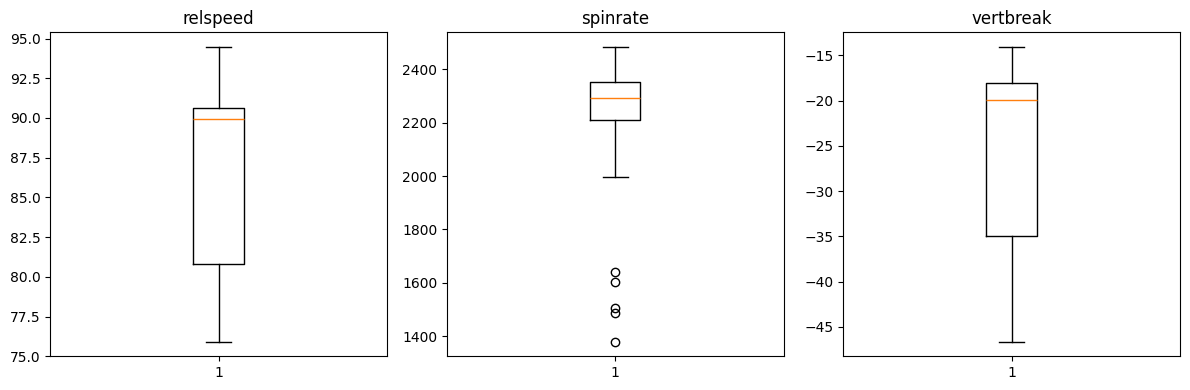

In [20]:
cols = ['relspeed', 'spinrate', 'vertbreak'] 

fig, axes = plt.subplots(1, 3, figsize=(12,4))

for ax, col in zip(axes, cols):
    ax.boxplot(dat[col].dropna())
    ax.set_title(col)

plt.tight_layout()
plt.show()

These plots tell me that the pitcher is comfortable throwing above 80 miles per hour and frequently throws with a spinrate above 2000. This pitcher is definitely strong with pitches that rely on speed. The vertical break boxplot also tells me that pitches mostly fell between 18 and 35 inches. While the lower end of this range signals concern for a pitcher who relies on speed, the upper end is a good range for fast balls.

I now will plot the speed of each pitch throughout the game on a line plot to assess the pitcher's ability to maintain pressure. 

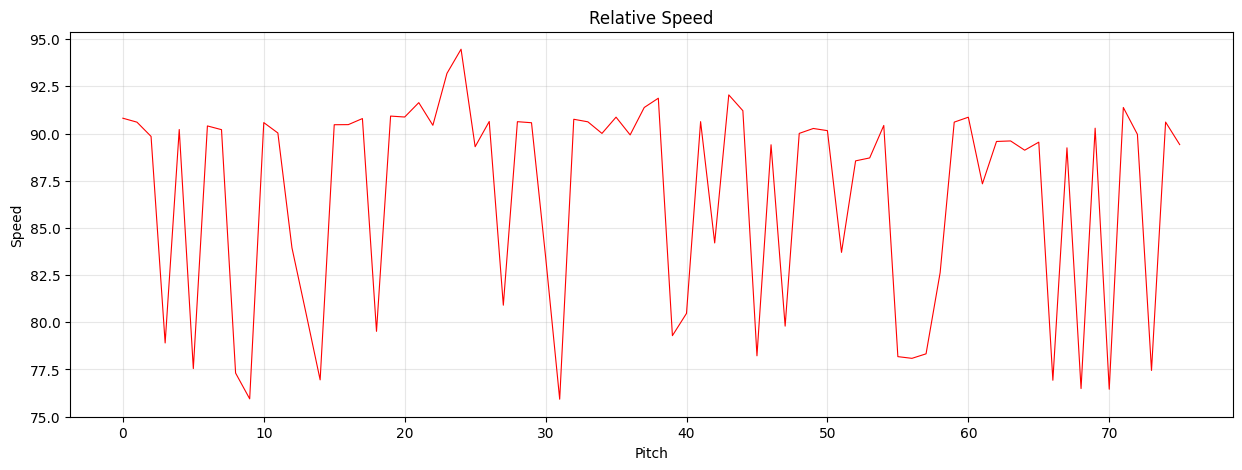

In [21]:
plt.figure(figsize=(15,5))
plt.plot(dat['relspeed'], linewidth=0.8, color = 'red')
plt.title('Relative Speed')
plt.xlabel('Pitch')
plt.ylabel('Speed')
plt.grid(True, alpha=0.3)
plt.show()

It appears this pitcher threw most of their fastest pitches between their 20th and 40th pitch, but the surrounding pitches show much less consistency. After pitch 40, the pitcher seems to throw much more pitches below 80 miles per hour. It would be necessary for this pitcher to work on their opening pitches as well as staying consistent through later innings. 

Using the plot_strike_zone function from the pybaseball.plotting library, I can make an intuitive Strike zone graphic and plot pitches. First I will need to clean the set to match the required formatting of the function. 

In [22]:
# Create a duplicate of original data set
zone_dat = dat.copy(deep=True)
# Rename columns to math pybaseball formatting
zone_dat = zone_dat.rename(columns={'taggedpitchtype' : 'pitch_type',
                               'platelocside' : 'plate_x',
                               'platelocheight' : 'plate_z'})

# Define codes to represent pitch types
name_to_code = {
    'Fastball':'FF',
    'Slider':'SL',
    'ChangeUp':'CU'
}
zone_dat['pitch_type'] = dat['taggedpitchtype'].map(name_to_code)

# Validate that cleaning produced the correct output
print(zone_dat['pitch_type'].unique())


['FF' 'SL' 'CU']


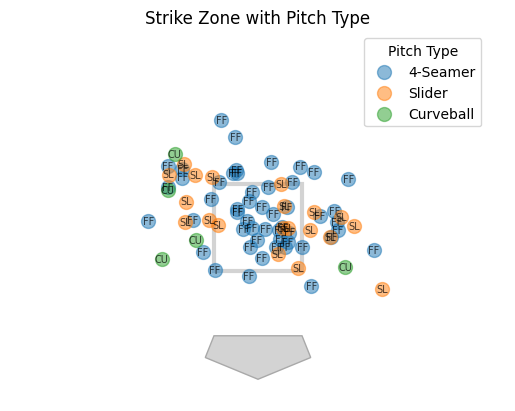

<Axes: title={'center': 'Strike Zone with Pitch Type'}>

In [23]:
# Plot Strike Zone with plotted pitches colored by Pitch Type
plot_strike_zone(zone_dat, 
                title = 'Strike Zone with Pitch Type')

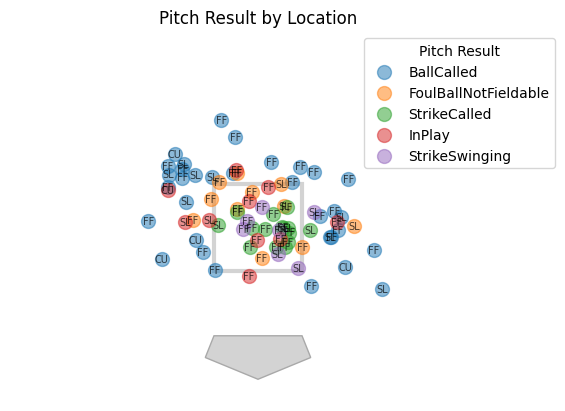

<Axes: title={'center': 'Pitch Result by Location'}>

In [24]:
# Plot Strike Zone with plotted pitches colored by pitch result
plot_strike_zone(zone_dat, 
                 title='Pitch Result by Location',
                colorby = 'pitchcall',
                legend_title = 'Pitch Result')

The first graphic reveals that the pitcher was consistent in placing fastballs around the strike zone. However, there are a considerable number of fastballs that fall far outside of the zone. The second graphic that colors by pitch result shows that pitches inside resulted in strike calls often, both with and without swings. Still, these pitches are easier to make contact with, which is reflected by the number of balls that were hit foul or into play in the second plot. These are areas of concern for a pitcher who has a limited list of pitch types. 